# 06 — Product Co-occurrence & Cancellations

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

### Load Data
`customer_df` from `data/processed/`.

In [2]:
customer_df = pd.read_csv('../data/processed/customer_df.csv')

# Product Family Mapping
Group StockCodes that are colour/pattern variants of the same base product, using `Description` text — needed to tell "reordered the exact item" apart from "kept a different variant of the same item."

In [3]:
# family = numeric stem shared across StockCode variants (e.g. 85099B/85099C/85099F 
# are colour variants of the same product)
customer_df['stockcode_upper'] = customer_df['StockCode'].str.upper()
customer_df['product_family'] = customer_df['stockcode_upper'].str.extract(r'^(\d{4,6})')[0]

In [4]:
# sanity check: show a handful of families found (base string -> list of StockCodes/Descriptions)
# and spot-check a few by eye that they're plausible variants of the same product, not unrelated items
customer_df.groupby('product_family').agg({'StockCode': lambda x: list(x.unique()),
                                           'Description': lambda x: list(x.unique())}).sample(10)

,StockCode,Description
product_family,,
22694,[22694],[WICKER STAR ]
21415,[21415],[CLAM SHELL SMALL ]
22865,[22865],[HAND WARMER OWL DESIGN]
23102,[23102],[SILVER HEARTS TABLE DECORATION]
23516,[23516],[EMBROIDERED RIBBON REEL SOPHIE ]
23250,[23250],"[VINTAGE RED TRIM ENAMEL BOWL , ENAMEL BOWL PA..."
90040,"[90040A, 90040B, 90040C]","[MURANO STYLE GLASS BRACELET RED, MURANO STYLE..."
21518,[21518],[BANK ACCOUNT GREETING CARD ]
22429,[22429],[ENAMEL MEASURING JUG CREAM]


# Cancellation Match Classification
For each cancelled invoice, look for a same-customer, nearby (±7 days) non-cancelled invoice and classify the match:
- **Same StockCode** — reorder/correction signal
- **Same product family, different StockCode** — "sampled variants, kept one" signal
- **No match** — unrelated / dissatisfaction, not explained by variant sampling

In [5]:
# TODO: for each cancelled invoice (is_cancelled == True), find same-customer invoices
# within +/-7 days that are NOT cancelled
customer_df['InvoiceDate'] = pd.to_datetime(customer_df['InvoiceDate'])

cancelled = customer_df[customer_df['is_cancelled']][['Customer ID','Invoice','InvoiceDate','StockCode','product_family']]
noncancelled = customer_df[~customer_df['is_cancelled']][['Customer ID','InvoiceDate','StockCode','product_family']]

merged = cancelled.merge(noncancelled, on='Customer ID', suffixes=('_c','_n'))
merged['days_diff'] = (merged['InvoiceDate_n'] - merged['InvoiceDate_c']).dt.days
merged = merged[merged['days_diff'].abs() <= 7]

merged['same_stockcode'] = merged['StockCode_c'] == merged['StockCode_n']
merged['same_family'] = merged['product_family_c'] == merged['product_family_n']

match = merged.groupby('Invoice')[['same_stockcode','same_family']].any()
match['bucket'] = 'no_match'
match.loc[match['same_family'], 'bucket'] = 'same_family'
match.loc[match['same_stockcode'], 'bucket'] = 'same_stockcode'

all_cancelled = cancelled['Invoice'].unique()
match = match.reindex(all_cancelled, fill_value='no_match')['bucket'].fillna('no_match')

match.value_counts()

bucket
no_match          1928
same_stockcode    1719
same_family          7
Name: count, dtype: int64

# Results
What % of cancelled invoices fall into each of the three buckets — this determines which story (reorder, variant-sampling, or unrelated dissatisfaction) actually explains the cancellation pattern.

**What each bucket means:**
- `same_stockcode` — the cancelled item reappears in a non-cancelled order within 7 days. Looks like a reorder/correction, not variant-sampling.
- `same_family` — a *different* StockCode from the same product family shows up in a nearby non-cancelled order (e.g. cancelled the green version, kept the rose one). This is the bucket that actually tests the "sample multiple variants, keep one" hypothesis.
- `no_match` — no nearby related order at all. Looks like genuine dissatisfaction or an unrelated cancellation.

In [6]:
# TODO: breakdown table — count and % of cancelled invoices per bucket
counts = match.value_counts()
percentage = (counts / counts.sum() * 100).round(1)

breakdown = pd.DataFrame({'count': counts, 'percentage': percentage})
breakdown

,count,percentage
bucket,,
no_match,1928,52.8
same_stockcode,1719,47.0
same_family,7,0.2


<Axes: xlabel='bucket'>

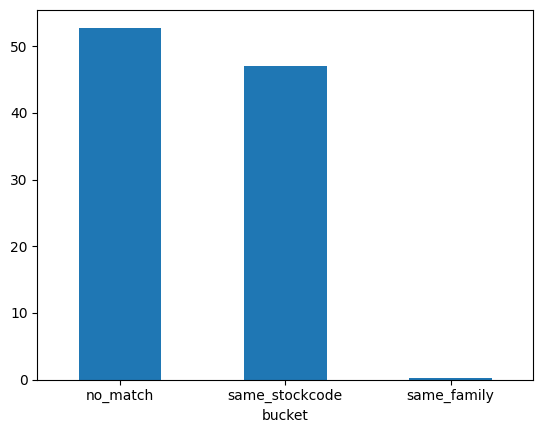

In [7]:
# TODO: bar chart of the three bucket proportions
breakdown.plot(kind='bar', y='percentage', legend=False,rot=0)

# Actionable Insights

The original hypothesis — that cancellations reflect customers sampling multiple colour/pattern variants and keeping one — is not supported by the data. Same-family matches (different variant, same product line) account for only 0.2% of cancelled invoices (7 of 3,654), ruling this out as a meaningful driver.

Instead, two other patterns dominate:

1. **Same-StockCode reorders (47.0%)** — nearly half of cancellations involve the exact same product reappearing in a non-cancelled order within 7 days. This looks like a correction/reorder pattern (wrong item, damaged item, or a fulfillment issue prompting a redo) rather than browsing behavior. Worth investigating with ops/fulfillment: are these customers getting the wrong size, a damaged item, or a shipping error that requires reordering?

2. **No related order at all (52.8%)** — the majority of cancellations have no nearby matching or related order, suggesting standalone dissatisfaction or unrelated cancellations not explained by either pattern tested here.

Business takeaway: there's no bundling opportunity to pursue here — customers are not routinely buying variant sets and keeping one, so a "pick your favorite from a pack" offer wouldn't be grounded in actual behavior. The more promising lead is the same-StockCode reorder pattern: if even a portion of that 47% reflects fulfillment errors rather than customer preference changes, that's a fixable operational cost, not a merchandising one.